In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
#from matplotlib_venn import venn2, venn3
import seaborn as sns
from ALLCools.mcds import MCDS 

In [2]:
#data loading
base_dir = '/ceph/MethDev/pbio'
mcds_dir='/ceph/MethDev/Natanella_mCT/novaseq_demux'
mcds_path = f'{mcds_dir}/All_mcds.mcds'
rna_path = f'{base_dir}/novaseq_demux/count.csv'
meta_path =f'{base_dir}/data/Arab6_cells_and_clusters.csv'

mcds = MCDS.open(mcds_paths = mcds_path, var_dim = 'gene')
rna_matrix = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path)


In [3]:
meta

,Cell,Cluster
0,NJ_221007_P1.2.K15.J3,1
1,NJ_221007_P1.2.K15.E16,12
2,NJ_221007_P1.2.K15.C15,4
3,NJ_221007_P1.2.K15.J4,1
4,NJ_221007_P1.2.K15.M16,4
...,...,...
3317,JW_240119_Arab_P.4.I3.H7,1
3318,JW_240119_Arab_P.4.I3.I7,1
3319,JW_240119_Arab_P.4.I3.P8,0
3320,JW_240119_Arab_P.4.I3.E8,0


In [4]:
#get methylation fraction 
mCGN_mc = mcds.sel(
    mc_type = 'CGN',
    count_type = 'mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(
    mc_type = 'CGN',
    count_type = 'cov').gene_da.to_pandas()
mCGN_frac = mCGN_mc.div(mCGN_cov).fillna(0)

In [5]:
mCGN_frac

gene,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ATCG01220,ATCG01230,ATCG01240,ATCG01250,ATCG01260,ATCG01270,ATCG01280,ATCG01290,ATCG01300,ATCG01310
cell,,,,,,,,,,,,,,,,,,,,,
NJ_221007_P1-2-K15-I15,0.081633,0.000000,0.0,0.0,0.641618,0.000000,0.0,0.192308,0.0,0.157303,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NJ_221007_P1-2-K15-A3,0.044444,0.277778,0.0,0.0,0.645349,0.000000,1.0,0.120000,0.0,0.222222,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NJ_221007_P1-2-K15-I16,0.011765,0.000000,0.0,0.0,0.593939,0.047619,1.0,0.175000,0.0,0.294872,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NJ_221007_P1-2-K15-I3,0.000000,0.000000,0.0,0.0,0.625000,0.000000,0.0,0.285714,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NJ_221007_P1-2-K15-D3,0.071429,0.000000,0.0,0.0,0.474074,0.000000,0.0,0.142857,0.0,0.140000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-B9,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NJ_221007_P8-5-G10-O10,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NJ_221007_P8-5-G10-I10,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
#re-format and combine clusters
meta['Cell'] = meta['Cell'].str.replace('.','-')
meta = meta.set_index('Cell')
meta['Cluster'] = meta['Cluster'].replace({6:1,0:1,4:1,5:3})

In [7]:
meta

,Cluster
Cell,
NJ_221007_P1-2-K15-J3,1
NJ_221007_P1-2-K15-E16,12
NJ_221007_P1-2-K15-C15,1
NJ_221007_P1-2-K15-J4,1
NJ_221007_P1-2-K15-M16,1
...,...
JW_240119_Arab_P-4-I3-H7,1
JW_240119_Arab_P-4-I3-I7,1
JW_240119_Arab_P-4-I3-P8,1


In [8]:
#assign cluster to meth data
mCGN_frac['cluster'] = meta['Cluster']
#exclude cluster 2/9
# mCGN_frac = mCGN_frac[~mCGN_frac['cluster'].isin([2])]
# mCGN_frac = mCGN_frac[~mCGN_frac['cluster'].isin([9])]
mCGN_frac

gene,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ATCG01230,ATCG01240,ATCG01250,ATCG01260,ATCG01270,ATCG01280,ATCG01290,ATCG01300,ATCG01310,cluster
cell,,,,,,,,,,,,,,,,,,,,,
NJ_221007_P1-2-K15-I15,0.081633,0.000000,0.0,0.0,0.641618,0.000000,0.0,0.192308,0.0,0.157303,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
NJ_221007_P1-2-K15-A3,0.044444,0.277778,0.0,0.0,0.645349,0.000000,1.0,0.120000,0.0,0.222222,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
NJ_221007_P1-2-K15-I16,0.011765,0.000000,0.0,0.0,0.593939,0.047619,1.0,0.175000,0.0,0.294872,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
NJ_221007_P1-2-K15-I3,0.000000,0.000000,0.0,0.0,0.625000,0.000000,0.0,0.285714,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0
NJ_221007_P1-2-K15-D3,0.071429,0.000000,0.0,0.0,0.474074,0.000000,0.0,0.142857,0.0,0.140000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-B9,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
NJ_221007_P8-5-G10-O10,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
NJ_221007_P8-5-G10-I10,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


In [9]:
cluster_meth_matrix = mCGN_frac.groupby('cluster').mean().T
filtered_meth_df = cluster_meth_matrix[cluster_meth_matrix.apply(lambda x: (x >= 0.1).any(), axis=1)]
filtered_meth_df

cluster,1.0,2.0,3.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
gene,,,,,,,,,,,
AT1G01040,0.564792,0.499131,0.544494,0.559987,0.510824,0.168949,0.543102,0.496080,0.431320,0.567724,0.504161
AT1G01046,0.170675,0.088905,0.152712,0.132120,0.075815,0.042553,0.123377,0.123932,0.029412,0.269333,0.062500
AT1G01050,0.102364,0.060269,0.092611,0.074367,0.103065,0.019752,0.063770,0.104978,0.071767,0.086700,0.073958
AT1G01060,0.094478,0.082114,0.102627,0.077231,0.085111,0.024436,0.099430,0.112388,0.055685,0.066262,0.182099
AT1G01220,0.280770,0.250437,0.274247,0.232565,0.267154,0.073125,0.313288,0.294860,0.200417,0.289716,0.225925
...,...,...,...,...,...,...,...,...,...,...,...
ATMG01370,0.239582,0.139795,0.232398,0.148686,0.107596,0.010993,0.074212,0.153437,0.065357,0.299172,0.241776
ATMG01380,0.225876,0.130831,0.230904,0.143520,0.167309,0.038116,0.099562,0.138211,0.119950,0.222028,0.320312
ATMG01390,0.601476,0.451379,0.592524,0.423849,0.525949,0.126299,0.432388,0.481862,0.389476,0.566530,0.401918


In [10]:
# get gene index for methylation values exceeding certain threshold
filtered_index = filtered_meth_df.index

In [11]:
#filter cluster information
rna_matrix['cluster'] = meta['Cluster'].replace({6:1,0:1,4:1,5:3})
# rna_matrix = rna_matrix[~rna_matrix['cluster'].isin([2])]
cluster_rna_matrix = rna_matrix.groupby('cluster').mean().T
cluster_rna_matrix

cluster,1.0,2.0,3.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
AT1G01010,2.517454,0.037791,0.821569,11.107595,0.917293,6.978723,10.272727,5.679487,0.980392,20.04,0.1250
AT1G01020,44.494182,15.168605,28.056863,33.322785,44.932331,6.425532,29.935065,36.628205,15.941176,96.24,19.8750
AT1G01030,10.394935,8.904070,3.798039,4.727848,10.789474,0.000000,9.077922,0.269231,25.176471,8.20,0.0625
AT1G01040,51.211499,27.770349,37.413725,32.734177,42.120301,5.542553,23.051948,50.910256,55.568627,87.16,77.6250
AT1G01046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
ATMG09730,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.0000
ATMG09740,0.004107,0.203488,0.037255,0.037975,0.060150,0.000000,0.000000,0.000000,0.000000,0.08,0.0000
ATMG09950,0.000000,0.014535,0.000000,0.000000,0.090226,0.000000,0.000000,0.000000,0.000000,0.00,0.0000
ATMG09960,0.009582,0.008721,0.001961,0.006329,0.015038,0.000000,0.000000,0.000000,0.000000,0.00,0.0000


In [12]:
filtered_rna_df = cluster_rna_matrix.reindex(filtered_index)
filtered_rna_df

cluster,1.0,2.0,3.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
gene,,,,,,,,,,,
AT1G01040,51.211499,27.770349,37.413725,32.734177,42.120301,5.542553,23.051948,50.910256,55.568627,87.16,77.6250
AT1G01046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.0000
AT1G01050,28.195072,7.360465,5.539216,16.993671,5.676692,1.468085,11.714286,22.192308,16.803922,39.12,8.8125
AT1G01060,202.393566,63.476744,78.592157,68.582278,78.849624,16.074468,63.987013,96.000000,118.588235,218.96,155.2500
AT1G01220,12.114990,2.790698,11.519608,8.196203,3.624060,0.074468,11.688312,14.576923,5.705882,32.36,12.1875
...,...,...,...,...,...,...,...,...,...,...,...
ATMG01370,0.261465,0.061047,0.162745,0.151899,0.000000,0.000000,1.792208,2.141026,0.000000,2.84,0.2500
ATMG01380,0.052019,0.046512,0.019608,0.018987,0.037594,0.063830,0.116883,0.038462,0.039216,0.00,0.0000
ATMG01390,0.989733,0.584302,0.894118,1.424051,0.518797,0.436170,1.441558,1.448718,0.274510,0.76,0.3125


In [13]:
corr_values = filtered_meth_df.corrwith(filtered_rna_df, axis =1)
corr_values

gene
AT1G01040    0.507070
AT1G01046         NaN
AT1G01050    0.471203
AT1G01060    0.312755
AT1G01220    0.552124
               ...   
ATMG01370    0.336693
ATMG01380   -0.663255
ATMG01390    0.302924
ATMG01400   -0.149909
ATMG01410    0.340244
Length: 11740, dtype: float64

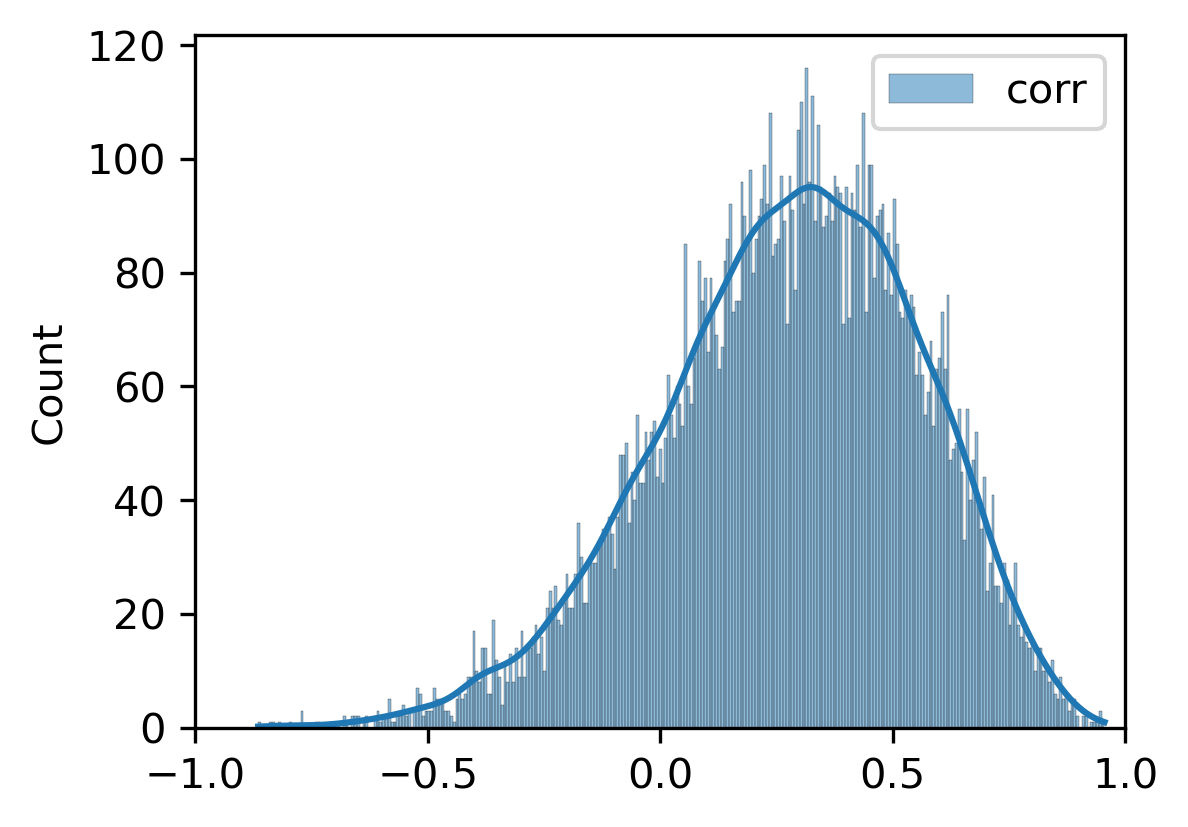

In [14]:
fig, ax = plt.subplots(figsize = (4,3), dpi = 300)
sns.histplot(corr_values, ax = ax,kde=True,bins=300, label = 'corr')
# sns.distplot(corr_df_diagonal_values_2, ax = ax,kde=True,bins=300, label = 'corr')
# sns.distplot(s_corr_df_diagonal_values,ax = ax, kde=True,bins=300, label = 'shuffle')

ax.set_xlim(-1,1)
# ax.axvline(x=0, color='red', linestyle='--', label='baseline')
# ax.set_xlabel(f'{mc_type} {condition} chr{chromosome}')
plt.legend()
# fig.savefig(f'./results/0413_filtered_exclude2_9_mc_rna_correlation.pdf', bbox_inches='tight')

In [15]:
#NOTE: arbitrary threshold for zscore filtering!!!
thres = -0.3
(corr_values<=thres).sum() # 335 genes

335

In [16]:
below_threshold = corr_values[corr_values<=thres]
thres_mc_df = filtered_meth_df.loc[below_threshold.index]
thres_mc_df

cluster,1.0,2.0,3.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
gene,,,,,,,,,,,
AT1G05087,0.094917,0.053168,0.084073,0.050828,0.117614,0.028154,0.067857,0.049401,0.113725,0.112211,0.002604
AT1G06790,0.146872,0.107074,0.135068,0.129786,0.108822,0.037672,0.174629,0.098824,0.134451,0.183498,0.054854
AT1G08460,0.014036,0.017261,0.015846,0.108008,0.015234,0.013607,0.053565,0.030872,0.027856,0.004997,0.066926
AT1G09160,0.061909,0.043515,0.146281,0.160625,0.125827,0.035995,0.130679,0.078706,0.153360,0.058512,0.186340
AT1G09190,0.119504,0.081547,0.134386,0.123586,0.098138,0.019492,0.096676,0.151511,0.141707,0.124509,0.083093
...,...,...,...,...,...,...,...,...,...,...,...
ATMG00830,0.183162,0.066434,0.171843,0.119502,0.131306,0.058511,0.069388,0.172106,0.151261,0.106667,0.101562
ATMG01090,0.365700,0.197754,0.357295,0.272101,0.282271,0.068500,0.224837,0.293258,0.112365,0.409252,0.353739
ATMG01220,0.225160,0.111096,0.225445,0.096406,0.104510,0.029255,0.122602,0.220814,0.110007,0.215545,0.075000


In [17]:
df_zscore = thres_mc_df.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
df_zscore

cluster,1.0,2.0,3.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
gene,,,,,,,,,,,
AT1G05087,0.651379,-0.458448,0.363102,-0.520657,1.254734,-1.123409,-0.067966,-0.558589,1.151365,1.111094,-1.802605
AT1G06790,0.617644,-0.271680,0.353869,0.235858,-0.232629,-1.822553,1.237920,-0.456045,0.340097,1.436109,-1.438590
AT1G08460,-0.627135,-0.523085,-0.568745,2.404823,-0.588496,-0.640975,0.648238,-0.083927,-0.181254,-0.918788,1.079344
AT1G09160,-0.859804,-1.207203,0.733757,1.004664,0.347441,-1.349241,0.439073,-0.542544,0.867450,-0.923955,1.490362
AT1G09190,0.344385,-0.679784,0.745943,0.454527,-0.232122,-2.354197,-0.271569,1.207996,0.943466,0.479438,-0.638084
...,...,...,...,...,...,...,...,...,...,...,...
ATMG00830,1.381096,-1.215147,1.129333,-0.034812,0.227733,-1.391369,-1.149443,1.135179,0.671547,-0.320296,-0.433822
ATMG01090,0.914420,-0.641641,0.836540,0.047200,0.141431,-1.839206,-0.390711,0.243226,-1.432791,1.317935,0.803596
ATMG01220,1.228549,-0.409712,1.232650,-0.620696,-0.504293,-1.585156,-0.244445,1.166132,-0.425344,1.090458,-0.928142


In [18]:
#drop 2 and 9 or not, that is the question
df_zscore = df_zscore.drop(columns=[2.0,9.0], axis = 0)

In [19]:
df_zscore

cluster,1.0,3.0,7.0,8.0,10.0,11.0,12.0,13.0,14.0
gene,,,,,,,,,
AT1G05087,0.651379,0.363102,-0.520657,1.254734,-0.067966,-0.558589,1.151365,1.111094,-1.802605
AT1G06790,0.617644,0.353869,0.235858,-0.232629,1.237920,-0.456045,0.340097,1.436109,-1.438590
AT1G08460,-0.627135,-0.568745,2.404823,-0.588496,0.648238,-0.083927,-0.181254,-0.918788,1.079344
AT1G09160,-0.859804,0.733757,1.004664,0.347441,0.439073,-0.542544,0.867450,-0.923955,1.490362
AT1G09190,0.344385,0.745943,0.454527,-0.232122,-0.271569,1.207996,0.943466,0.479438,-0.638084
...,...,...,...,...,...,...,...,...,...
ATMG00830,1.381096,1.129333,-0.034812,0.227733,-1.149443,1.135179,0.671547,-0.320296,-0.433822
ATMG01090,0.914420,0.836540,0.047200,0.141431,-0.390711,0.243226,-1.432791,1.317935,0.803596
ATMG01220,1.228549,1.232650,-0.620696,-0.504293,-0.244445,1.166132,-0.425344,1.090458,-0.928142


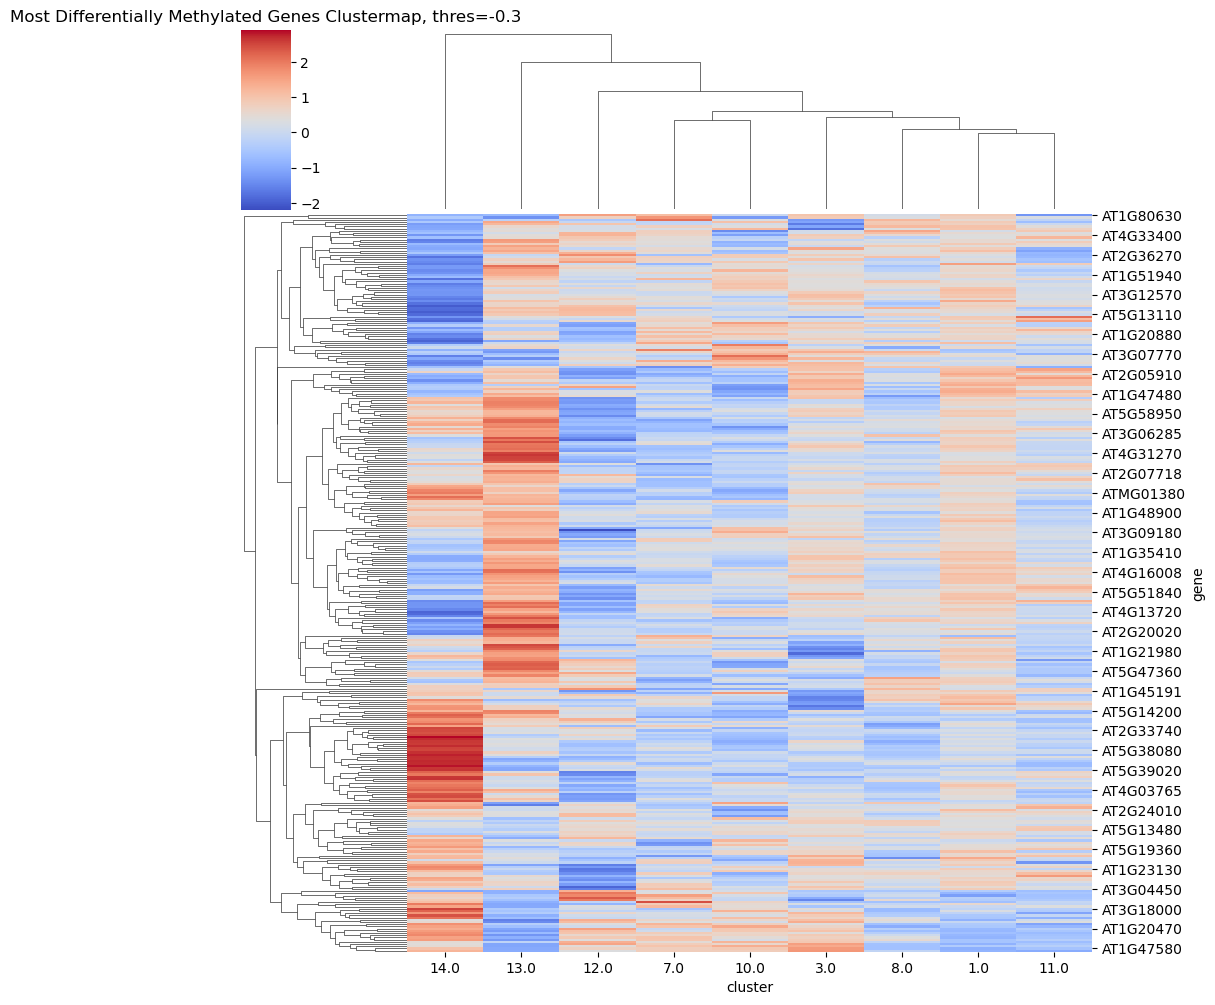

In [20]:
cluster = sns.clustermap(df_zscore, method='average', metric='euclidean', cmap='coolwarm', figsize=(10, 10))

plt.title(f'Most Differentially Methylated Genes Clustermap, thres={thres}')
# plt.savefig('./result/highMCClusterMap.pdf')
plt.show()

In [21]:
gene_order = cluster.dendrogram_row.reordered_ind
seurat_order = cluster.dendrogram_col.reordered_ind
thres_rna_df = filtered_rna_df.loc[below_threshold.index].drop(columns=[2.0,9.0], axis = 0)
#thres_rna_df = filtered_rna_df.loc[below_threshold.index]
thres_rna_df_reordered = thres_rna_df.iloc[gene_order,seurat_order]

In [22]:
# meth_aligned_rna_df = filtered_rna_df.iloc[gene_order,seurat_order]
# meth_aligned_rna_df
# thres_rna_df_reordered = thres_rna_df_reordered.drop(columns=[2.0,9.0], axis = 0)
thres_rna_df_reordered

cluster,14.0,13.0,12.0,7.0,10.0,3.0,8.0,1.0,11.0
gene,,,,,,,,,
AT1G80630,14.1875,0.00,2.235294,3.088608,6.805195,4.780392,1.263158,2.941821,12.410256
AT5G17900,40.1250,107.08,9.470588,21.854430,24.246753,19.274510,15.744361,26.375086,22.474359
AT3G50570,0.0000,0.00,0.000000,0.000000,0.129870,2.209804,0.030075,0.427789,0.076923
AT2G04570,0.0000,0.04,2.490196,0.006329,0.025974,6.111765,0.022556,0.101300,0.128205
AT4G18970,0.6250,0.00,0.039216,0.006329,0.441558,23.609804,0.969925,0.485284,14.461538
...,...,...,...,...,...,...,...,...,...
AT3G45140,9.0625,16.00,6.098039,7.443038,4.103896,6.303922,20.225564,86.539357,78.448718
AT2G10940,11.4375,14.00,4.568627,39.848101,17.961039,25.270588,35.112782,118.169747,90.538462
AT5G51460,0.2500,23.28,3.745098,0.449367,10.402597,3.725490,20.639098,19.468857,25.179487


In [23]:
rna_zscore = thres_rna_df_reordered.apply(lambda x: (x - x.mean()) / x.std(), axis=1)
# rna_zscore

<Axes: xlabel='cluster', ylabel='gene'>

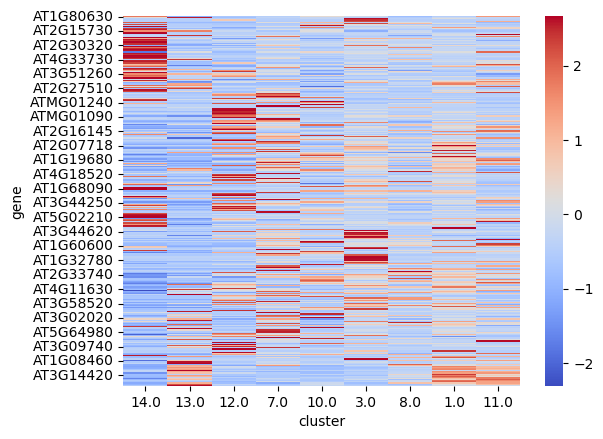

In [24]:
sns.heatmap(rna_zscore,cmap = 'coolwarm')

In [25]:
# number of top genes per cluster
top_n = 10

top_genes_per_cluster = {}

for cluster in rna_zscore.columns:
    # sort genes by z-score (descending = highest expression)
    top_genes = rna_zscore[cluster].sort_values(ascending=False).head(top_n)
    top_genes_per_cluster[cluster] = top_genes.index.tolist()

# print results nicely
for cluster, genes in top_genes_per_cluster.items():
    print(f"\nCluster {cluster}:")
    for g in genes:
        print(f"  {g}")


Cluster 14.0:
  AT3G59510
  AT1G16960
  AT1G23170
  AT3G58640
  AT5G02210
  AT5G39160
  AT5G42970
  AT1G68090
  AT3G26500
  AT2G14740

Cluster 13.0:
  AT4G38550
  AT5G39020
  AT3G14630
  AT5G48380
  AT5G38865
  AT3G57550
  AT2G39110
  AT2G26300
  AT5G17900
  AT2G34100

Cluster 12.0:
  AT2G29410
  AT5G09215
  AT5G64240
  AT4G15990
  AT5G64687
  AT5G43380
  AT1G23130
  AT4G16008
  AT2G21650
  ATMG01090

Cluster 7.0:
  AT2G23540
  AT1G64000
  AT1G52750
  AT1G47480
  AT2G05910
  AT1G24430
  AT4G17280
  AT1G09460
  AT4G16620
  AT4G01470

Cluster 10.0:
  AT2G07724
  AT2G06667
  ATMG00830
  AT3G02020
  AT2G29710
  AT1G04923
  AT5G14200
  AT2G14750
  AT1G64310
  AT2G24010

Cluster 3.0:
  AT2G05370
  AT1G11303
  AT2G15050
  AT1G32780
  AT3G09450
  AT1G62030
  AT5G38530
  AT2G33060
  AT1G29435
  AT3G26450

Cluster 8.0:
  AT5G28010
  AT2G14390
  AT5G08490
  AT1G31630
  AT2G21727
  AT3G18000
  AT4G11810
  AT4G01330
  AT5G01105
  AT4G00490

Cluster 1.0:
  AT3G04725
  AT2G07718
  AT5G05625
  AT2G40